# **Game Analysis**
 
Aggregate statistics describing each game as a whole, independent of the models.
 
## **Setup**
 
### **Imports**

In [1]:
import pathlib

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

from cambench.eval import game_table

ROOT = pathlib.Path.cwd().parent  # notebooks/ -> project root
RUNS = ROOT / "data" / "runs"
RUN_DIR = str(sorted(RUNS.iterdir())[-1])  # latest run; or set one explicitly

plt.rcParams["axes.grid"] = True  # half-transparent grid lines
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["figure.titlesize"] = 16  # suptitle larger than subplot titles
print("RUN_DIR:", RUN_DIR)

df = pd.DataFrame(game_table(RUN_DIR))


def count_pct(total):
  """autopct that labels each pie slice with its raw count and percentage."""
  return lambda pct: f"{round(pct / 100 * total)} ({pct:.0f}%)"

RUN_DIR: /Users/luozihyuan/Developer/camelot-bench/data/runs/260911142213-0700


## **Outcomes**
 
Win distribution, terminal conditions, and the side balance over the run.

### **Distribution**

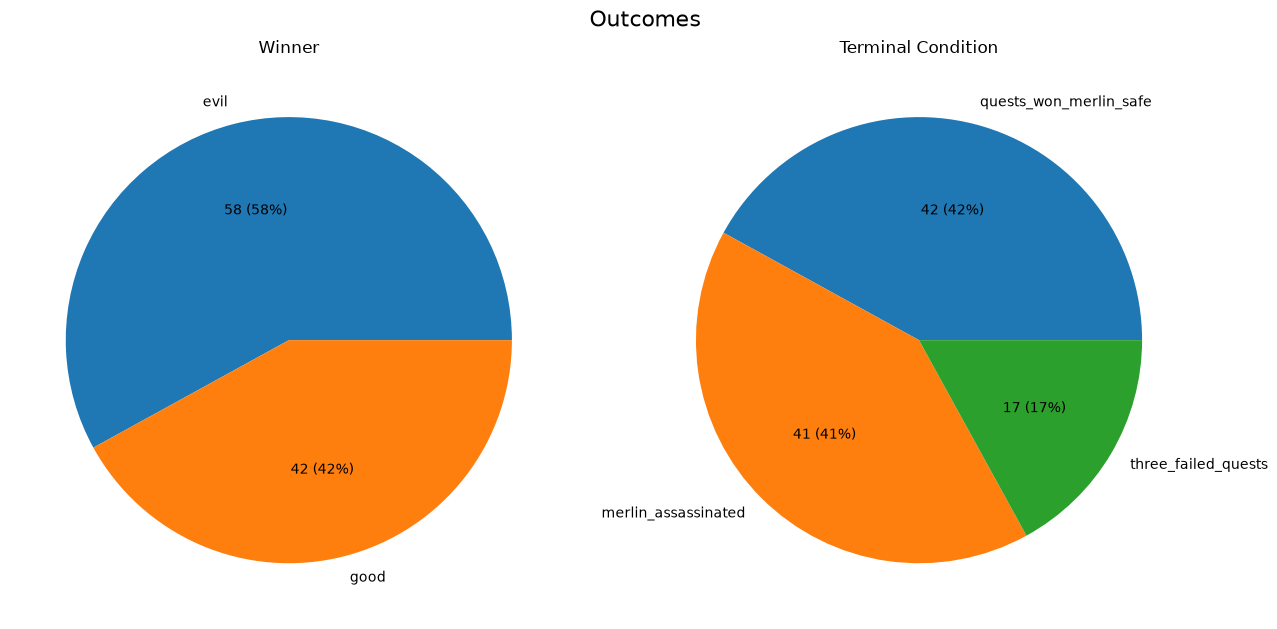

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
fig.suptitle("Outcomes")
df["winner"].value_counts().plot(kind="pie", ax=axes[0], title="Winner", ylabel="", autopct=count_pct(len(df)))
df["reason"].value_counts().plot(kind="pie", ax=axes[1], title="Terminal Condition", ylabel="", autopct=count_pct(len(df)))
plt.tight_layout()
plt.show()

### **Win Rate Trend**

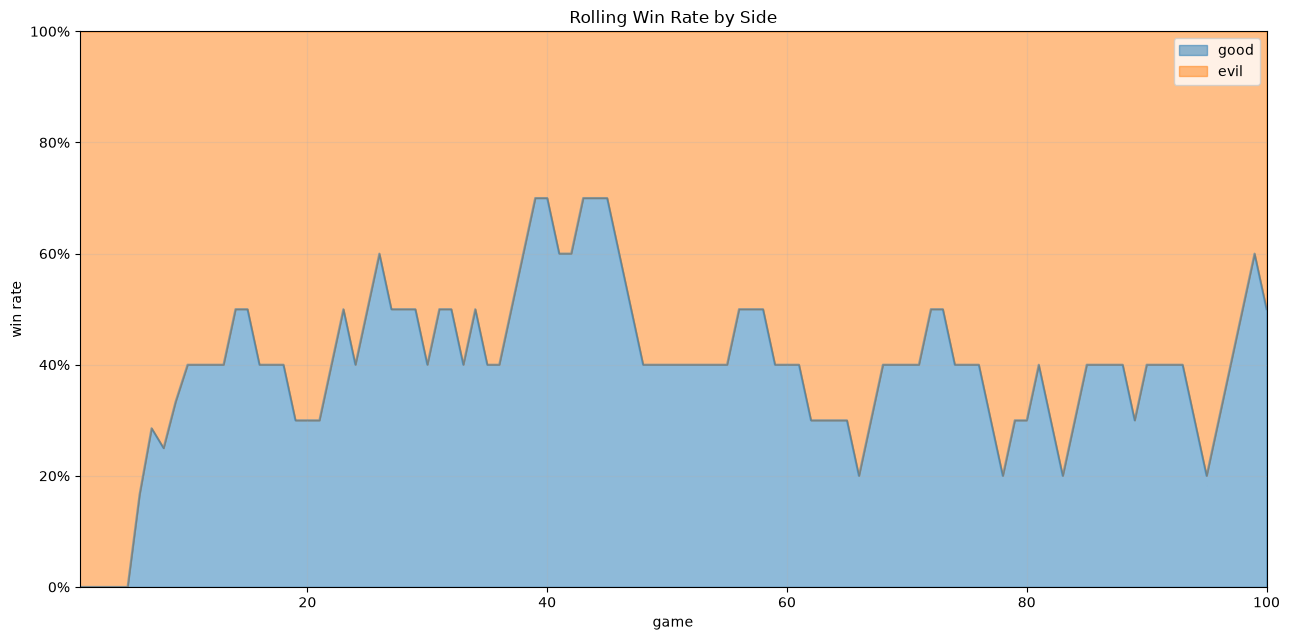

In [3]:
good = df.assign(g=(df["winner"] == "good").astype(int)).set_index("game")["g"].rolling(10, min_periods=1).mean()
sides = pd.DataFrame({"good": good, "evil": 1 - good})
ax = sides.plot(
  kind="area",
  stacked=True,
  alpha=0.5,
  figsize=(13, 6.5),
  ylim=(0, 1),
  xlim=(df["game"].min(), df["game"].max()),
  title="Rolling Win Rate by Side",
  xlabel="game",
  ylabel="win rate",
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## **Game Structure**
 
Proposals per game. The box plot reports the quartiles; a long upper whisker indicates a tail of extended games.

### **Length**


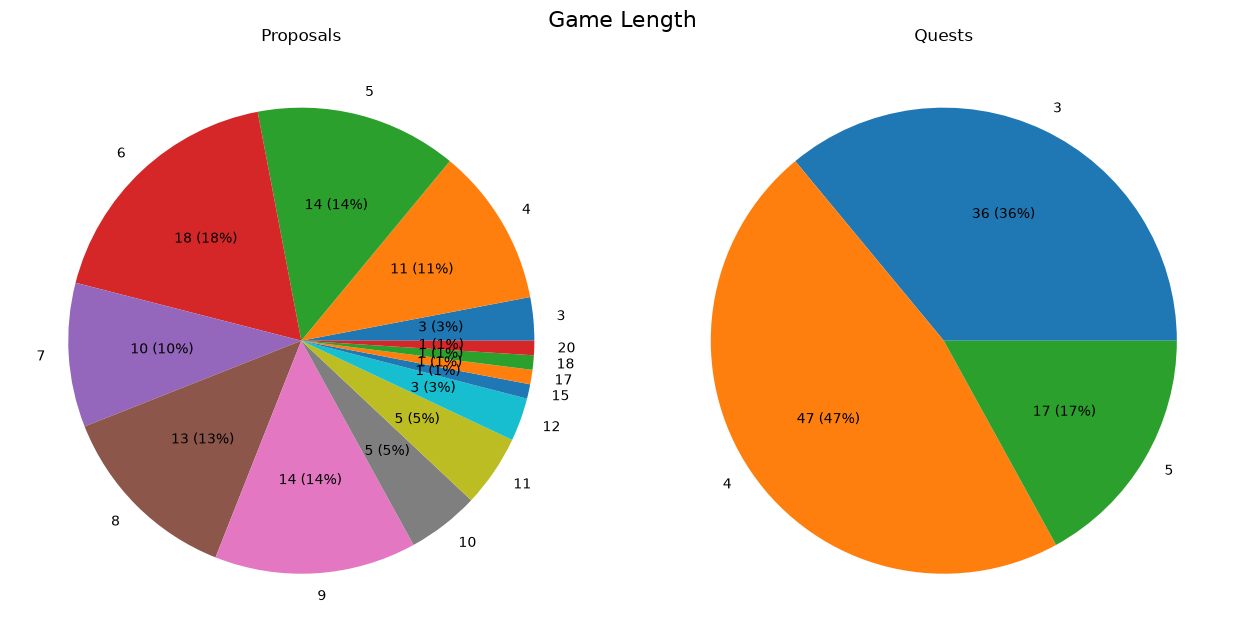

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
fig.suptitle("Game Length")
df["proposals"].value_counts().sort_index().plot(
  kind="pie", ax=axes[0], title="Proposals", ylabel="", autopct=count_pct(len(df))
)
df["quests_played"].value_counts().sort_index().plot(
  kind="pie", ax=axes[1], title="Quests", ylabel="", autopct=count_pct(len(df))
)
plt.tight_layout()
plt.show()

### **Rejections and Failures**


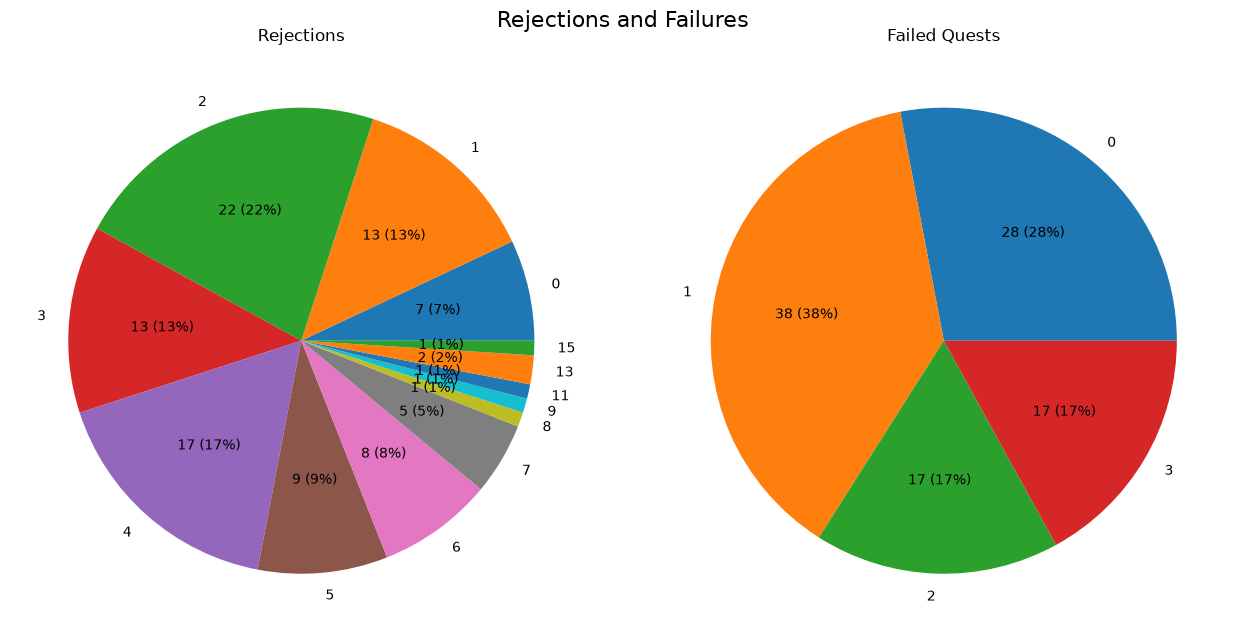

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
fig.suptitle("Rejections and Failures")
df["rejections"].value_counts().sort_index().plot(
  kind="pie", ax=axes[0], title="Rejections", ylabel="", autopct=count_pct(len(df))
)
df["fails"].value_counts().sort_index().plot(
  kind="pie", ax=axes[1], title="Failed Quests", ylabel="", autopct=count_pct(len(df))
)
plt.tight_layout()
plt.show()

### **Stats over the Run**

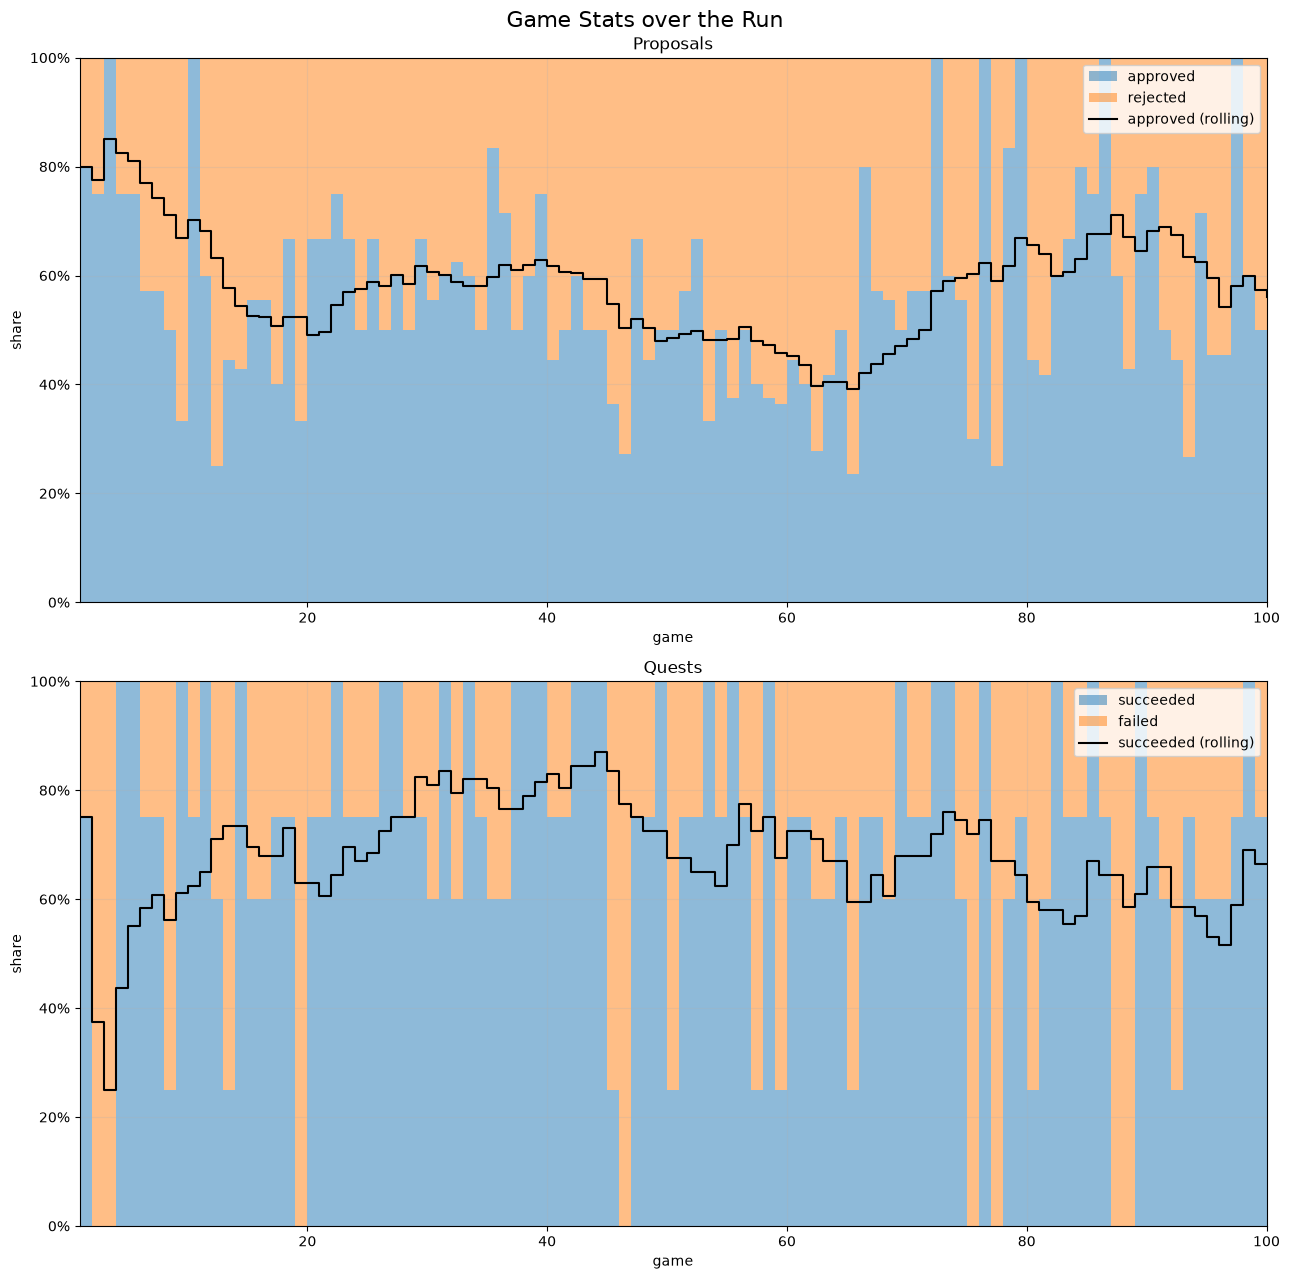

In [6]:
g = df.set_index("game")
props = pd.DataFrame(
  {
    "approved": (g["proposals"] - g["rejections"]) / g["proposals"],
    "rejected": g["rejections"] / g["proposals"],
  }
)
quests = pd.DataFrame(
  {
    "succeeded": (g["quests_played"] - g["fails"]) / g["quests_played"],
    "failed": g["fails"] / g["quests_played"],
  }
)

fig, axes = plt.subplots(2, 1, figsize=(13, 13))
fig.suptitle("Game Stats over the Run")
panels = [(axes[0], props, "Proposals", "approved"), (axes[1], quests, "Quests", "succeeded")]
for ax, frame, title, boundary in panels:
  ax.stackplot(frame.index, *[frame[c] for c in frame], labels=list(frame), step="post", alpha=0.5)
  frame[boundary].rolling(10, min_periods=1).mean().plot(
    ax=ax, color="black", linewidth=1.5, drawstyle="steps-post", label=f"{boundary} (rolling)"
  )
  ax.set_title(title)
  ax.set_ylabel("share")
  ax.set_ylim(0, 1)
  ax.set_xlim(df["game"].min(), df["game"].max())
  ax.set_xlabel("game")
  ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
  ax.legend(loc="upper right")
plt.tight_layout()
plt.show()